<a href="https://colab.research.google.com/github/Pinguill/challenge-telecom-latam/blob/main/Challenge_TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [57]:
import pandas as pd

In [58]:
df_clientes = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
df_clientes

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [59]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [60]:
df_clientes.shape

(7267, 6)

In [61]:
df_clientes.describe(include='all')

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [62]:
df_clientes['customerID'].duplicated().sum()

np.int64(0)

In [63]:
df_clientes['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [64]:
df_clientes['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [65]:
df_clientes[
    df_clientes['Churn'] == ''
] = 'No definido'
df_clientes['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
No definido,224


In [66]:
def resumen_nulos(df):
    return pd.DataFrame({
        'nulos': df.isna().sum(),
        'porcentaje': df.isna().mean() * 100
    }).sort_values(by='porcentaje', ascending=False)

In [67]:
def valores_unicos(df):
    for col in df.select_dtypes(include='object').columns:
        print(f"\n{col}")
        print(df[col].value_counts())


## **Analisis inicial de datos "Customer"**

In [68]:
customer = pd.concat(
    [
        df_clientes[['customerID', 'Churn']],
        pd.json_normalize(df_clientes['customer'])
    ],
    axis=1
)
customer

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure
0,0002-ORFBO,No,Female,0.0,Yes,Yes,9.0
1,0003-MKNFE,No,Male,0.0,No,No,9.0
2,0004-TLHLJ,Yes,Male,0.0,No,No,4.0
3,0011-IGKFF,Yes,Male,1.0,Yes,No,13.0
4,0013-EXCHZ,Yes,Female,1.0,Yes,No,3.0
...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0.0,No,No,13.0
7263,9992-RRAMN,Yes,Male,0.0,Yes,No,22.0
7264,9992-UJOEL,No,Male,0.0,No,No,2.0
7265,9993-LHIEB,No,Male,0.0,Yes,Yes,67.0


In [69]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customerID     7267 non-null   object 
 1   Churn          7267 non-null   object 
 2   gender         7043 non-null   object 
 3   SeniorCitizen  7043 non-null   float64
 4   Partner        7043 non-null   object 
 5   Dependents     7043 non-null   object 
 6   tenure         7043 non-null   float64
dtypes: float64(2), object(5)
memory usage: 397.5+ KB


In [70]:
resumen_nulos(customer)

,nulos,porcentaje
gender,224,3.082427
Partner,224,3.082427
SeniorCitizen,224,3.082427
Dependents,224,3.082427
tenure,224,3.082427
Churn,0,0.000000
customerID,0,0.000000


In [71]:
valores_unicos(customer)


customerID
customerID
No definido    224
6625-UTXEW       1
6625-IUTTT       1
6625-FLENO       1
6624-JDRDS       1
              ... 
3351-NQLDI       1
3351-NGXYI       1
3349-ANQNH       1
3348-CFRNX       1
3372-CDXFJ       1
Name: count, Length: 7044, dtype: int64

Churn
Churn
No             5174
Yes            1869
No definido     224
Name: count, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


## **Analisis inicial de datos "phone"**

In [72]:
client_phone = pd.concat(
    [
        df_clientes[['customerID']],
        pd.json_normalize(df_clientes['phone'])
    ],
    axis=1
)
client_phone

,customerID,PhoneService,MultipleLines
0,0002-ORFBO,Yes,No
1,0003-MKNFE,Yes,Yes
2,0004-TLHLJ,Yes,No
3,0011-IGKFF,Yes,No
4,0013-EXCHZ,Yes,No
...,...,...,...
7262,9987-LUTYD,Yes,No
7263,9992-RRAMN,Yes,Yes
7264,9992-UJOEL,Yes,No
7265,9993-LHIEB,Yes,No


In [73]:
client_phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7267 non-null   object
 1   PhoneService   7043 non-null   object
 2   MultipleLines  7043 non-null   object
dtypes: object(3)
memory usage: 170.4+ KB


In [74]:
resumen_nulos(client_phone)

,nulos,porcentaje
PhoneService,224,3.082427
MultipleLines,224,3.082427
customerID,0,0.000000


In [75]:
valores_unicos(client_phone)


customerID
customerID
No definido    224
6625-UTXEW       1
6625-IUTTT       1
6625-FLENO       1
6624-JDRDS       1
              ... 
3351-NQLDI       1
3351-NGXYI       1
3349-ANQNH       1
3348-CFRNX       1
3372-CDXFJ       1
Name: count, Length: 7044, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


## **Analisis inicial de datos "Internet"**

In [76]:
client_internet = pd.concat(
    [
        df_clientes[['customerID']],
        pd.json_normalize(df_clientes['internet'])
    ],
    axis=1)
client_internet

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0002-ORFBO,DSL,No,Yes,No,Yes,Yes,No
1,0003-MKNFE,DSL,No,No,No,No,No,Yes
2,0004-TLHLJ,Fiber optic,No,No,Yes,No,No,No
3,0011-IGKFF,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,0013-EXCHZ,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,DSL,Yes,No,No,Yes,No,No
7263,9992-RRAMN,Fiber optic,No,No,No,No,No,Yes
7264,9992-UJOEL,DSL,No,Yes,No,No,No,No
7265,9993-LHIEB,DSL,Yes,No,Yes,Yes,No,Yes


In [77]:
client_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   InternetService   7043 non-null   object
 2   OnlineSecurity    7043 non-null   object
 3   OnlineBackup      7043 non-null   object
 4   DeviceProtection  7043 non-null   object
 5   TechSupport       7043 non-null   object
 6   StreamingTV       7043 non-null   object
 7   StreamingMovies   7043 non-null   object
dtypes: object(8)
memory usage: 454.3+ KB


In [78]:
resumen_nulos(client_internet)

,nulos,porcentaje
InternetService,224,3.082427
OnlineSecurity,224,3.082427
OnlineBackup,224,3.082427
DeviceProtection,224,3.082427
StreamingTV,224,3.082427
TechSupport,224,3.082427
StreamingMovies,224,3.082427
customerID,0,0.000000


In [79]:
valores_unicos(client_internet)


customerID
customerID
No definido    224
6625-UTXEW       1
6625-IUTTT       1
6625-FLENO       1
6624-JDRDS       1
              ... 
3351-NQLDI       1
3351-NGXYI       1
3349-ANQNH       1
3348-CFRNX       1
3372-CDXFJ       1
Name: count, Length: 7044, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

StreamingTV
StreamingTV
No                     281

## **Analisis inicial de datos "Account"**

In [80]:
client_account = pd.concat(
    [
        df_clientes[['customerID']],
        pd.json_normalize(df_clientes['account'])
    ],
    axis=1
)
client_account

,customerID,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...
7262,9987-LUTYD,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,Two year,No,Mailed check,67.85,4627.65


In [81]:
client_account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Contract          7043 non-null   object 
 2   PaperlessBilling  7043 non-null   object 
 3   PaymentMethod     7043 non-null   object 
 4   Charges.Monthly   7043 non-null   float64
 5   Charges.Total     7043 non-null   object 
dtypes: float64(1), object(5)
memory usage: 340.8+ KB


In [82]:
resumen_nulos(client_account)

,nulos,porcentaje
Contract,224,3.082427
PaperlessBilling,224,3.082427
Charges.Monthly,224,3.082427
PaymentMethod,224,3.082427
Charges.Total,224,3.082427
customerID,0,0.000000


In [83]:
valores_unicos(client_account)


customerID
customerID
No definido    224
6625-UTXEW       1
6625-IUTTT       1
6625-FLENO       1
6624-JDRDS       1
              ... 
3351-NQLDI       1
3351-NGXYI       1
3349-ANQNH       1
3348-CFRNX       1
3372-CDXFJ       1
Name: count, Length: 7044, dtype: int64

Contract
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

PaperlessBilling
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

PaymentMethod
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Charges.Total
Charges.Total
20.2       11
           11
19.75       9
19.9        8
19.65       8
           ..
829.55      1
625.65      1
462.8       1
251.25      1
3121.45     1
Name: count, Length: 6531, dtype: int64


#🔧 Transformación

In [84]:
import numpy as np

In [85]:
client_account['Charges.Total'] = client_account['Charges.Total'].replace(' ', '0.0')
client_account

,customerID,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...
7262,9987-LUTYD,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,Two year,No,Mailed check,67.85,4627.65


In [86]:
client_account['Charges.Total'] = client_account['Charges.Total'].astype(np.float64)
client_account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Contract          7043 non-null   object 
 2   PaperlessBilling  7043 non-null   object 
 3   PaymentMethod     7043 non-null   object 
 4   Charges.Monthly   7043 non-null   float64
 5   Charges.Total     7043 non-null   float64
dtypes: float64(2), object(4)
memory usage: 340.8+ KB


In [87]:
client_account['Cuentas_Diarias'] = (client_account['Charges.Monthly'] / 30).round(2)


#📊 Carga y análisis

In [88]:
def analisis_descriptivo(df):
  return df.describe(include='all')

In [89]:
analisis_descriptivo(client_account)

,customerID,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267,7043,7043,7043,7043.000000,7043.000000,7043.000000
unique,7044,3,2,4,NaN,NaN,NaN
top,No definido,Month-to-month,Yes,Electronic check,NaN,NaN,NaN
freq,224,3875,4171,2365,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,64.761692,2279.734304,2.158675
std,NaN,NaN,NaN,NaN,30.090047,2266.794470,1.003088
min,NaN,NaN,NaN,NaN,18.250000,0.000000,0.610000
25%,NaN,NaN,NaN,NaN,35.500000,398.550000,1.180000
50%,NaN,NaN,NaN,NaN,70.350000,1394.550000,2.340000
75%,NaN,NaN,NaN,NaN,89.850000,3786.600000,2.990000


In [90]:
analisis_descriptivo(client_internet)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
count,7267,7043,7043,7043,7043,7043,7043,7043
unique,7044,3,3,3,3,3,3,3
top,No definido,Fiber optic,No,No,No,No,No,No
freq,224,3096,3498,3088,3095,3473,2810,2785


In [91]:
analisis_descriptivo(client_phone)

,customerID,PhoneService,MultipleLines
count,7267,7043,7043
unique,7044,2,3
top,No definido,Yes,No
freq,224,6361,3390


In [92]:
customer.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure'],
      dtype='object')

# **Graficas de valores cualitativos**

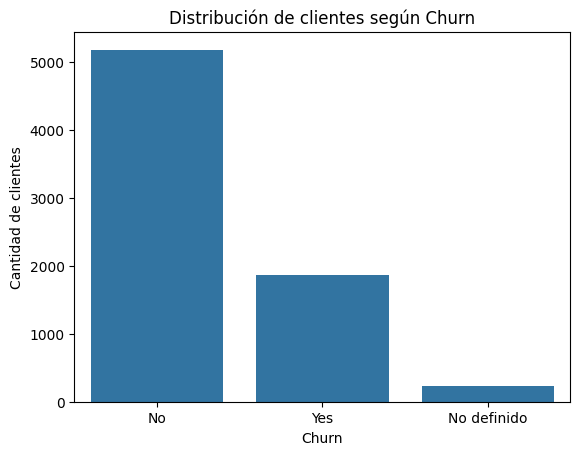

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_clientes, x='Churn')
plt.title('Distribución de clientes según Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.show()

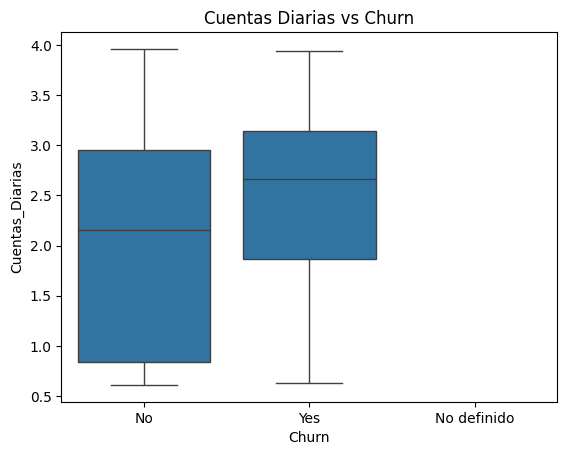

In [94]:
account_churn = client_account.merge(
    customer[['customerID', 'Churn']],
    on='customerID'
)

sns.boxplot(data=account_churn, x='Churn', y='Cuentas_Diarias')
plt.title('Cuentas Diarias vs Churn')
plt.show()

In [99]:
def estilizar_countplot(ax):
    # Quitar bordes superior y derecho
    sns.despine(ax=ax)

    # Quitar eje Y
    ax.set_ylabel('')
    ax.set_yticks([])

    # Agregar valores encima de las barras
    for container in ax.containers:
        ax.bar_label(
            container,
            label_type='edge',
            fontsize=10,
            padding=3
        )


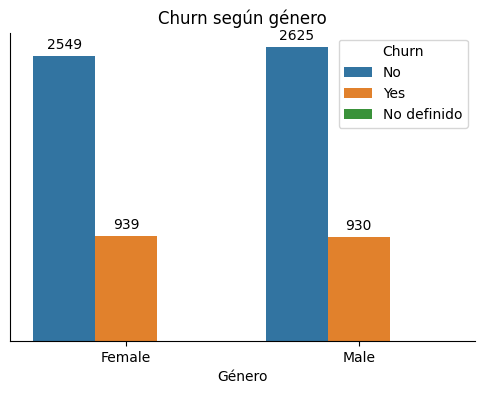

In [103]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=customer,
    x='gender',
    hue='Churn'
)

ax.set_title('Churn según género')
ax.set_xlabel('Género')

estilizar_countplot(ax)

plt.show()


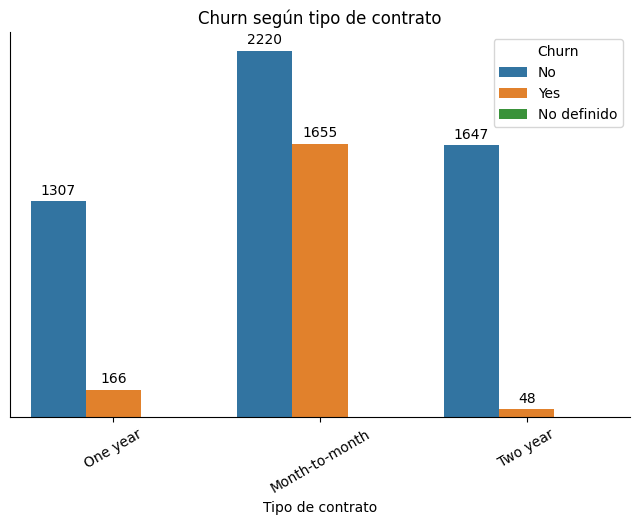

In [105]:
plt.figure(figsize=(8, 5))

contract_churn = client_account.merge(
    customer[['customerID', 'Churn']],
    on='customerID'
)

ax = sns.countplot(
    data=contract_churn,
    x='Contract',
    hue='Churn'
)

ax.set_title('Churn según tipo de contrato')
ax.set_xlabel('Tipo de contrato')
plt.xticks(rotation=30)

estilizar_countplot(ax)

plt.show()

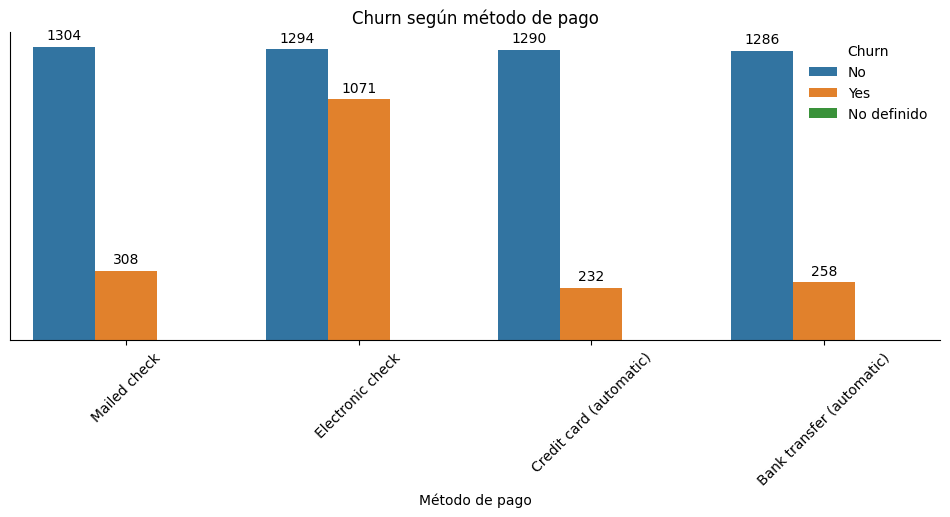

In [109]:
payment_churn = client_account.merge(
    customer[['customerID', 'Churn']],
    on='customerID'
)

plt.figure(figsize=(12, 4))

ax = sns.countplot(
    data=payment_churn,
    x='PaymentMethod',
    hue='Churn'
)

ax.set_title('Churn según método de pago')
ax.set_xlabel('Método de pago')
plt.xticks(rotation=45)

ax.legend(title='Churn', frameon=False)

estilizar_countplot(ax)

plt.show()

## **Graficos de valores cuantitativos**

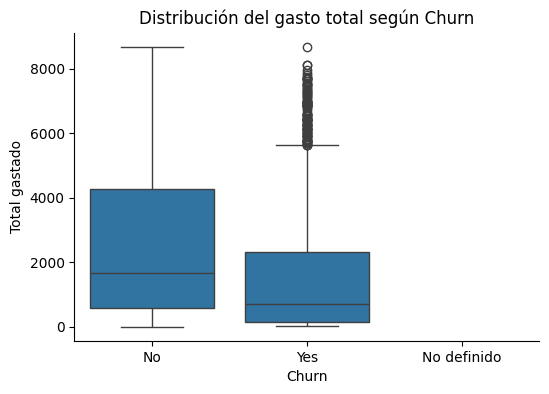

In [111]:
account_churn = client_account.merge(
    customer[['customerID', 'Churn']],
    on='customerID'
)

plt.figure(figsize=(6, 4))

ax = sns.boxplot(
    data=account_churn,
    x='Churn',
    y='Charges.Total'
)

ax.set_title('Distribución del gasto total según Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Total gastado')

sns.despine(ax=ax)

plt.show()


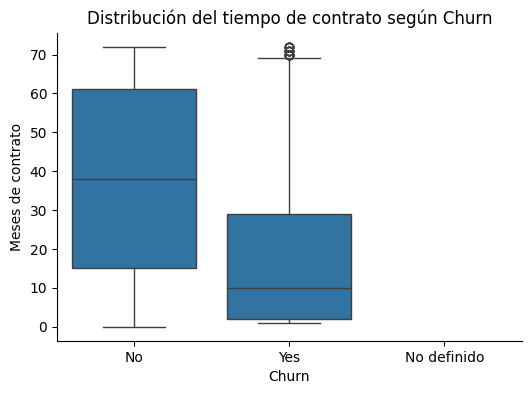

In [110]:
plt.figure(figsize=(6, 4))

ax = sns.boxplot(
    data=customer,
    x='Churn',
    y='tenure'
)

ax.set_title('Distribución del tiempo de contrato según Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Meses de contrato')

sns.despine(ax=ax)

plt.show()


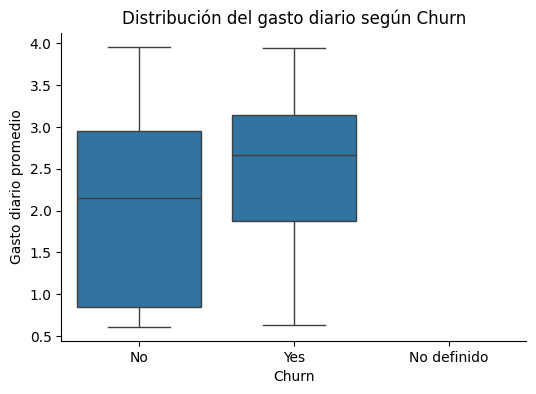

In [112]:
plt.figure(figsize=(6, 4))

ax = sns.boxplot(
    data=account_churn,
    x='Churn',
    y='Cuentas_Diarias'
)

ax.set_title('Distribución del gasto diario según Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Gasto diario promedio')

sns.despine(ax=ax)

plt.show()


#📄Informe final

## 1. Introducción
El objetivo de este análisis es comprender el fenómeno de **evasión de clientes (Churn)** y detectar patrones que permitan identificar los factores asociados a la cancelación del servicio.

La evasión de clientes representa un problema crítico para el negocio, ya que adquirir nuevos clientes suele ser más costoso que retener los existentes. A través de un Análisis Exploratorio de Datos (EDA), se busca obtener insights que ayuden a la toma de decisiones estratégicas orientadas a la retención.



## 2. Limpieza y Tratamiento de Datos
Para garantizar la calidad del análisis, se realizaron los siguientes pasos:

- Importación de librerías necesarias (`pandas`, `numpy`, `matplotlib`, `seaborn`)
- Revisión de valores nulos y tratamiento de datos faltantes
- Conversión de variables a su tipo de dato correcto
- Normalización de la información, separando el dataset original en las siguientes tablas:
  - `customer`
  - `client_phone`
  - `client_internet`
  - `client_account`
- Creación de nuevas variables derivadas, como:
  - **Cuentas_Diarias**, calculada a partir de la facturación mensual

Este proceso permitió una mejor organización de los datos y facilitó el análisis por dimensiones específicas.



## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Análisis de Churn
Se analizó la proporción de clientes que permanecieron activos frente a los que cancelaron el servicio.

📌 **Hallazgos:**
- Se observa una proporción significativa de clientes que presentan churn.
- Esto justifica la necesidad de analizar variables explicativas adicionales.


### 3.2 Churn según Variables Categóricas
Se evaluó cómo se distribuye la evasión según distintas variables categóricas:

- Género
- Tipo de contrato
- Método de pago

📌 **Hallazgos principales:**
- Por genero la evasion de quienes siguen y quien no es muy similar tanto en el genero masculino como femenino.
- El pago por mes a mes es donde mas personas han evadido, mientras que los otros metodos de pago tienen mucho menos.
- En donde mas se evidencia la evacion es por medio del metodo de pago "Electronic check"

### 3.3 Análisis de Variables Numéricas
Se analizaron variables numéricas clave y su relación con el churn:

- **Total gastado**
- **Tiempo de contrato**
- **Cuentas Diarias**

📌 **Hallazgos:**
- Se nota que hay muchos datos atipicos de las personas que evadieron y dejaron el servicio. Donde se pude evidenciar pagos muy altos, pero tambien pagos con una media de 1000.
- Muchas personas se salen a inicios de contratos, hay que evidenciar que tiene similitud con anteriores análisis.



## 4. Conclusiones e Insights
A partir del análisis exploratorio se concluye que:

- El churn está fuertemente relacionado con el tipo de contrato y el tiempo de permanencia.
- Clientes con contratos de corto plazo presentan mayor riesgo de evasión.
- Variables financieras como el gasto total y la facturación diaria ayudan a identificar clientes en riesgo.
- Existen patrones claros que pueden ser utilizados para modelos predictivos o estrategias de retención.

## 5. Recomendaciones
Con base en los resultados obtenidos, se sugieren las siguientes acciones:

- Incentivar contratos de mayor duración mediante descuentos o beneficios.
- Implementar campañas de retención temprana para clientes con poco tiempo de permanencia.
- Monitorear clientes con bajo gasto acumulado o cambios abruptos en su facturación diaria.
- Analizar métodos de pago asociados y motivos por el cual evaden mas el pago online.

